# Study the misalignment between theoretical and actual profits as well as the associated loss of tax

Load packages

In [244]:
import pandas as pd
import pickle
%matplotlib inline

import tjn_tools
from tjn_tools.data_processing import *

import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

from config_new import YEAR_CBCR, YEAR_SOTJ

Define paths for input data

In [245]:
path_files = "../../data/raw/"
path_files_final_estimations = "../../data/final/estimations/"
path_files_final_analysis = "../../data/final/analysis/"
path_files_final_figures = "../../data/final/figures/"
path_figures = "../../figures/"
path_files_temp = "../../data/intermediate/"

In [246]:
## Input from notebook 1
etr_output = f"{path_files_final_estimations}{YEAR_CBCR}_cbcr_etr_rates_new.xlsx"
df_etrs = pd.read_excel(etr_output,index_col=0)
iso3_to_etr = df_etrs["ETR_total"].to_dict()

iso3_to_gdp_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_gdp_new.dump"
iso3_to_gdp = pickle.load(open(f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_gdp_new.dump","rb+"))

info_expenditures_output = f"{path_files_final_estimations}{YEAR_CBCR}_info_expenditures_new.csv"
cols_other_info = ['who_gvt_health_expenditure','govt_exp_educ_gdp',
        'total_taxes_revenue', 'iso3', 'gdp', 'population',
        'region_tjn']
other_info = pd.read_csv(info_expenditures_output, sep="\t", usecols=cols_other_info)

## Input from notebook 2
#Main results
final_data_output = f"{path_files_temp}{YEAR_CBCR}_replicates_new.csv"

iso3_to_cit_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_cit_new.dump"
iso3_to_wages_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_wages_new.dump"

iso3_to_cit = pickle.load(open(iso3_to_cit_output,"rb+"))
iso3_to_wages = pickle.load(open(iso3_to_wages_output,"rb+"))


# Count of observations (foreign and domestic countries)
iso3_to_count_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_count_new.dump"
iso3_to_dom_output = f"{path_files_final_estimations}{YEAR_CBCR}_iso3_to_dom_new.dump"
iso3_to_count = pickle.load(open(iso3_to_count_output,"rb+"))
iso3_to_dom = pickle.load(open(iso3_to_dom_output,"rb+"))

Define path for outputs

In [247]:
# Output
file_output = f"{YEAR_CBCR}_tax_avoidance_sotj_table_new_additionalcountries_correctforparticipation.xlsx"
sotj_table_output = f"{path_files_final_analysis}{file_output}"
sotj_table_output_workstream = f"{tjn_tools.paths.sharepoint_root}/TJN - Shared Documents/Workstreams/Scale of Tax Injustice/State of Tax Justice report/{YEAR_SOTJ} Report/Tax avoidance/{file_output}"

## Define function that calculates misalignment

In [248]:
def calculate_misalignment(df,
                           weights=[1/2,1/2,0,0],
                           pi_var="pi",
                           weights_var = ["revt","empt","t_at","wages"],
                          carve_out=None,
                          carve_out_perc=0,
                          thres_mis=0,
                          max_etr=0.25,
                          remove_misalignment=[]):
    """
    Calculate misalignment as a function of sales, employees, capital and wages
    
    In:
    df = data
    pi/rev/emp/cap/wages_var = variables with the profits/revenue/employees/capital/wages (None to discard)
    weights = weights of each of the variables. 
    
    Out:
    
    """
    
    #Make sure it is okay
    assert sum(weights)==1,"Weights need to sum up to 1"
    
    vars_keep = []
    weights_keep = []
    for i,var in enumerate(weights_var):
        if var is None:
            if weights[i] != 0:
                raise(Exception("Weight of None variable is nonzero"))
        else:
            if weights[i] > 0:
                vars_keep.append("share_{}".format(var))
                weights_keep.append(weights[i])
                df["share_{}".format(var)] = df[var]/df[var].sum()
    
#     print(weights_keep)
#     print(vars_keep)
    #Calculate the share of the economy
    df["share_economy"] = (df.loc[:,vars_keep]*weights_keep).sum(1,min_count=len(weights_keep))
    
    #Create carve out 
    if (carve_out is not None) and (carve_out_perc > 0):
        df[pi_var] = df[pi_var]-carve_out_perc*df[carve_out]
        df.loc[df[pi_var]<0,pi_var] = 0
    
    df["share_profits"] = df[pi_var]/df[pi_var].sum()

    #Adjustment for countries where we don't want to implement the misalignment method (in 2018 this is Saudi Arabia, because of their huge reported domestic profits of Aramco). For these countries, we just take the share of the economic activity instead of the share of profit.
    for country in remove_misalignment:
        df.loc[(df['iso3_o'] == country) & (df["iso3_d"] == country), "share_profits"] = df.loc[(df['iso3_o'] == country) & (df["iso3_d"] == country), "share_economy"]
    
    df["share_profits"] = df["share_profits"]/df["share_profits"].sum()
    
    #Theoretical profits
    df["pi_theo_mis"] = df[pi_var].sum()*df["share_economy"]
    
    #Misalignment
    df["misaligned_profits"] = df[pi_var]-df["pi_theo_mis"]

    #OVer threshold (x% of the profits can be misaligned)
    df.loc[(df["misaligned_profits"]>0)&(df["misaligned_profits"]<df["profits"]*thres_mis),"misaligned_profits"] = 0
    
    #Threshold adjustment
    df.loc[(df["misaligned_profits"]>0)&(df["etr"]>max_etr)&(df["Domestic"]!=1),"misaligned_profits"] = 0
    #Correct for discrepancies
    x = df["misaligned_profits"]

    pos_pr = x[x>0].sum()
    previous_pr = -x[x<0].sum()
#     print("Profit shifted {:2.1f} adjusted to {:2.1f}".format(previous_pr/1E9,pos_pr/1E9))
    df.loc[df["misaligned_profits"]<0,"misaligned_profits"] *= pos_pr/previous_pr


#     df["etr"] = df["p_iso3"].map(iso3_to_etr)
    
    #Total shifted (exclude resource-rich countries)
#     total_shifted = df.loc[(df["misaligned_profits"]>0)&(df["etr"]<0.15),"misaligned_profits"].sum() 
    
    return df

def plot_results(countries,w2c,restriction="Domestic MNCs",gains=False,show=True):
    """
    Plot the results for a set of countries
    
    ## Input
    countries: countries to plot (iso3)
    w2c: dictionary {country: color}
    restriction: domestic or mncs corporations
    gains: plot losses (False) or gains (True)
    show: show plot
    """
    
    if gains:
        mult = -1
    else:
        mult = 1

    plt.figure(figsize=(12,3))
    index = 0 
    cs = []
    title = ""
    for i,row in d.loc[d["iso3_d"].isin(countries)].iterrows():
        if restriction not in row["Domestic"]:
            continue
        cs.append(row["iso3_d"])
        for col in list(d.columns)[2:-1]:
            index += 1
            
            if row["iso3_d"] == sorted(countries)[-1]: #last coontry
                if isinstance(col,str):
                    label = col
                    title="Minimum misalignment"
       
                else:
                    if isinstance(col[0],str):
                        label = f"{col[0][:-5]} ({col[1]})"
                        title=["Variable","Carveout fraction"]                        
                    else:
                        label = [np.round(_,2) if _ != int(_) else int(_) for _ in col]
                        title=["Sales","Emp","Wages","TA"]
            else:
                label = None

            
            if isinstance(row[col],float):
                continue
            
            plt.scatter([index],[mult*100*row[col][2]],
                     color="k",label=None,zorder=9,s=5)                
            plt.plot([index,index],[mult*100*row[col][0],mult*100*row[col][4]],
                     color=w2c[col],lw=4,label=label,zorder=8)

        index += 5
        plt.plot([index-2,index-2],[mult*-15,mult*20],"--",color="lightgray")
    
    separation = len(list(d.columns)[2:-1])+5
    plt.plot([0,index],[0,0],"--",zorder=0,color="k")
    plt.gca().grid(axis="y")
    sns.despine(bottom=True,left=True)
    plt.ylabel("")
#     cs = sorted(countries)
    plt.xticks(range(3,separation*(len(cs)-1)+4,separation),[iso3_to_name(_).replace(" ","\n") for _ in cs])
    plt.xlim(0,index-4.5)

    # Put the legend out of the figure
    plt.legend(bbox_to_anchor=(1.05, 0.9), loc=2, borderaxespad=0.,frameon=False,title=title)
    if gains:
        plt.ylabel("Gains from formulary apportionment (% of GDP)")
    else:
        plt.ylabel("Profits shifted in (% of GDP)")
    plt.title(restriction)
    if show:
        plt.show()

def num(x):
    """
    Convert numbers of strings to floats
    """
    try:
        return float(x)
    except:
        return np.nan
    
    

In [249]:
# Include missing wages and corporate income tax rates from indicated source
iso3_to_wages['AIA'] = 74620.18/12  # https://www.salaryexpert.com/salary/area/netherlands/the-valley--anguilla 
iso3_to_wages['COK'] = 2913.46 # https://worldsalaries.com/average-salary-in-cook-islands/
iso3_to_wages['GGY'] = 9859.02 # https://www.salaryexplorer.com/average-salary-wage-comparison-guernsey-c90
iso3_to_wages['GIB'] = 4462 # https://worldsalaries.com/average-salary-in-gibraltar/
iso3_to_wages['GLP'] = 2277.85 #https://www.salaryexplorer.com/average-salary-wage-comparison-guadalupe-t1601 
iso3_to_wages['GUF'] = 16983.03/12 #https://www.insee.fr/en/statistiques/serie/001781953
iso3_to_wages['JEY'] = 1098.36*4 #https://www.gov.je/StatisticsPerformance/EmploymentEarnings/pages/earningsincomestatistics.aspx
iso3_to_wages['MAF'] = 46000/12 #https://www.sint-maarten.net/population/life
iso3_to_wages['TWN'] = 21689/12 #https://nhglobalpartners.com/countries/taiwan/hiring-employees/average-salary/
iso3_to_wages['WLF'] = 625.75 #https://www.salaryexplorer.com/average-salary-wage-comparison-wallis-and-futuna-c239
iso3_to_cit['CUB'] = 0.35 #https://taxfoundation.org/data/all/global/corporate-tax-rates-by-country-2022/
iso3_to_cit['MHL'] = 0 #https://www.consilium.europa.eu/en/press/press-releases/2023/02/14/taxation-british-virgin-islands-costa-rica-marshall-islands-and-russia-added-to-eu-list-of-non-cooperative-jurisdictions-for-tax-purposes/

iso3_to_wages = dict(sorted(iso3_to_wages.items(), key=lambda item: item[0]))
print(iso3_to_wages)

{'ABW': 1986.169974158921, 'AFG': 82.5182732413988, 'AGO': 291.116457197418, 'AIA': 6218.348333333332, 'ALB': 468.46, 'AND': 2610.6094277190073, 'ARE': 2910.6515671516745, 'ARG': 656.95, 'ARM': 226.33, 'ASM': 1026.2909955997409, 'ATG': 1290.8740007227477, 'AUS': 4911.0, 'AUT': 3268.88, 'AZE': 320.35, 'BDI': 44.35746612045089, 'BEL': 3793.23, 'BEN': 161.87793461737493, 'BFA': 192.68, 'BGD': 245.04750350913605, 'BGR': 691.59, 'BHR': 1772.7029111944992, 'BHS': 2088.3696142188337, 'BIH': 567.0633502968244, 'BLR': 537.39, 'BLZ': 608.98, 'BMU': 5597.415314430211, 'BOL': 991.49, 'BRA': 782.2, 'BRB': 1344.1457944119588, 'BRN': 2063.9282207652295, 'BTN': 230.21, 'BWA': 640.1817203700969, 'CAF': 72.57093484468372, 'CAN': 2937.478082789631, 'CHE': 7774.89, 'CHL': 1245.2028528468543, 'CHN': 1038.06, 'CIV': 270.88730973998133, 'CMR': 204.5618887077845, 'COD': 88.85243494340081, 'COG': 289.0053375762584, 'COK': 2913.46, 'COL': 644.6236484163182, 'COM': 192.31809161874142, 'CPV': 363.3616580680845, '

In [250]:
#Read main results and add etr,cit,wages    

df = pd.read_csv(final_data_output,sep="\t").reset_index(drop=True)
for col in list(df.columns)[2:]:
    df[col] = df[col].apply(num)
df = df.dropna()

df["wages_pred"] = df["iso3_d"].map(iso3_to_wages)*df["emp_pred"]*12
df["etr"] = df["iso3_d"].map(iso3_to_etr)
df["cit"] = df["iso3_d"].map(iso3_to_cit)
df["gdp"] = df["iso3_d"].map(iso3_to_gdp)

df.head()

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,n_rep,wages_pred,etr,cit,gdp
0,ARG,ARG,1.0,159354.000000,6.026053e+10,9.545845e+10,1.130656e+10,1.000000,159354.0,6.026053e+10,9.545845e+10,1.130656e+10,0.0,1.256251e+09,0.153573,0.3,5.248197e+11
1,ARG,AUS,0.0,1440.859991,7.195612e+08,2.639474e+08,3.016624e+07,1.176212,1225.0,6.117613e+08,2.244046e+08,2.564694e+07,0.0,1.135888e+07,0.153573,0.3,5.248197e+11
2,ARG,BMU,0.0,4648.390762,1.285334e+09,6.543243e+08,1.038179e+08,1.176212,3952.0,1.092774e+09,5.562978e+08,8.826462e+07,0.0,3.664512e+07,0.153573,0.3,5.248197e+11
3,ARG,BRA,0.0,26086.034998,6.423036e+09,2.500947e+09,6.723180e+08,1.176212,22178.0,5.460780e+09,2.126272e+09,5.715958e+08,0.0,2.056466e+08,0.153573,0.3,5.248197e+11
4,ARG,CHE,0.0,18761.761397,5.257114e+09,1.999226e+09,1.262483e+08,1.176212,15951.0,4.469528e+09,1.699715e+09,1.073346e+08,0.0,1.479065e+08,0.153573,0.3,5.248197e+11


In [251]:
# CHECK IF COUNTRIES HAVE EMP_PRED
# Filter rows where 'emp_pred' column is not NaN
filtered_rows = df[~df["emp_pred"].isna()]
# Get unique 'iso3_d' values from the filtered rows
unique_iso3_d = filtered_rows["iso3_d"].unique()
# Sort the unique 'iso3_d' values alphabetically
sorted_iso3_d = sorted(unique_iso3_d)
# Print each unique 'iso3_d' value
for iso3_d in sorted_iso3_d:
    print(iso3_d)

ABW
AFG
AGO
AIA
ALB
AND
ARE
ARG
ARM
ASM
ATG
AUS
AUT
AZE
BEL
BEN
BFA
BGD
BGR
BHR
BHS
BIH
BLR
BLZ
BMU
BOL
BRA
BRB
BRN
BTN
BWA
CAF
CAN
CHE
CHL
CHN
CIV
CMR
COD
COG
COK
COL
COM
CPV
CRI
CUB
CUW
CYM
CYP
CZE
DEU
DJI
DMA
DNK
DOM
DZA
ECU
EGY
ESP
EST
ETH
FIN
FJI
FRA
FRO
FSM
GAB
GBR
GEO
GGY
GHA
GIB
GIN
GLP
GMB
GNQ
GRC
GRD
GRL
GTM
GUF
GUM
GUY
HKG
HND
HRV
HTI
HUN
IDN
IMN
IND
IRL
IRN
IRQ
ISL
ISR
ITA
JAM
JEY
JOR
JPN
KAZ
KEN
KGZ
KHM
KNA
KOR
KWT
LAO
LBN
LBR
LBY
LCA
LIE
LKA
LSO
LTU
LUX
LVA
MAC
MAF
MAR
MCO
MDA
MDG
MDV
MEX
MHL
MKD
MLI
MLT
MMR
MNE
MNG
MNP
MOZ
MRT
MUS
MWI
MYS
NAM
NCL
NER
NGA
NIC
NLD
NOR
NPL
NZL
OMN
PAK
PAN
PER
PHL
PLW
PNG
POL
PRI
PRK
PRT
PRY
PYF
QAT
ROU
RUS
RWA
SAU
SDN
SEN
SGP
SLB
SLE
SLV
SRB
SSD
SUR
SVK
SVN
SWE
SWZ
SXM
SYC
SYR
TCA
TCD
TGO
THA
TJK
TKM
TLS
TTO
TUN
TUR
TWN
TZA
UGA
UKR
URY
USA
UZB
VCT
VEN
VGB
VIR
VNM
VUT
WLF
WSM
XKX
YEM
ZAF
ZMB
ZWE


In [252]:
# CHECK IF EMP_PRED != 0
# Filter rows where 'emp_pred' column is not equal to 0
filtered_rows = df[df["emp_pred"] != 0]

# Get unique 'iso3_d' values from the filtered rows
unique_iso3_d = filtered_rows["iso3_d"].unique()

# Sort the unique 'iso3_d' values alphabetically
sorted_iso3_d = sorted(unique_iso3_d)

# Print each unique 'iso3_d' value
for iso3_d in sorted_iso3_d:
    print(iso3_d)

ABW
AFG
AGO
AIA
ALB
AND
ARE
ARG
ARM
ASM
ATG
AUS
AUT
AZE
BEL
BEN
BFA
BGD
BGR
BHR
BHS
BIH
BLR
BLZ
BMU
BOL
BRA
BRB
BRN
BTN
BWA
CAF
CAN
CHE
CHL
CHN
CIV
CMR
COD
COG
COL
COM
CPV
CRI
CUB
CUW
CYM
CYP
CZE
DEU
DJI
DMA
DNK
DOM
DZA
ECU
EGY
ESP
EST
ETH
FIN
FJI
FRA
FRO
FSM
GAB
GBR
GEO
GGY
GHA
GIB
GIN
GLP
GMB
GNQ
GRC
GRD
GRL
GTM
GUF
GUM
GUY
HKG
HND
HRV
HTI
HUN
IDN
IMN
IND
IRL
IRN
IRQ
ISL
ISR
ITA
JAM
JEY
JOR
JPN
KAZ
KEN
KGZ
KHM
KNA
KOR
KWT
LAO
LBN
LBR
LBY
LCA
LIE
LKA
LSO
LTU
LUX
LVA
MAC
MAF
MAR
MCO
MDA
MDG
MDV
MEX
MHL
MKD
MLI
MLT
MMR
MNE
MNG
MNP
MOZ
MRT
MUS
MWI
MYS
NAM
NCL
NER
NGA
NIC
NLD
NOR
NPL
NZL
OMN
PAK
PAN
PER
PHL
PLW
PNG
POL
PRI
PRK
PRT
PRY
PYF
QAT
ROU
RUS
RWA
SAU
SDN
SEN
SGP
SLB
SLE
SLV
SRB
SSD
SUR
SVK
SVN
SWE
SWZ
SXM
SYC
SYR
TCA
TCD
TGO
THA
TJK
TLS
TTO
TUN
TUR
TWN
TZA
UGA
UKR
URY
USA
UZB
VCT
VEN
VGB
VIR
VNM
VUT
WLF
WSM
XKX
YEM
ZAF
ZMB
ZWE


In [253]:
#Test for finland
m = calculate_misalignment(df.loc[df["n_rep"]==1],weights=[0,0.5,0.5,0],
                                  weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                  carve_out=None,
                                  carve_out_perc=0,
                                  pi_var="profits",
                                 thres_mis=0,
                                 max_etr=0.15)
m = m.loc[m["iso3_o"]=="FIN",["iso3_d","share_economy","share_profits","misaligned_profits"]].sort_values(by="misaligned_profits")
m[["share_economy",'share_profits']] *= 1000
m.tail(10)

,iso3_d,share_economy,share_profits,misaligned_profits
3043,FIN,1.54562,2.561204,4.271533e+09


In [254]:
#Test for other countries
m = calculate_misalignment(df,weights=[0,0.5,0.5,0],
                                  weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                  carve_out=None,
                                  carve_out_perc=0,
                                  pi_var="profits",
                                 thres_mis=0,
                                 max_etr=0.15)
m = m.loc[m["iso3_d"]=="ARE",["iso3_d","share_economy","share_profits","misaligned_profits"]].sort_values(by="misaligned_profits")
m[["share_economy",'share_profits']] *= 1000
m.tail(10)

,iso3_d,share_economy,share_profits,misaligned_profits
1148198,ARE,0.000085,0.000858,0.0
1148199,ARE,0.000034,0.000112,0.0
1148201,ARE,0.000001,0.000005,0.0
1148202,ARE,0.000009,0.000037,0.0
1148203,ARE,0.000007,0.000937,0.0
1148208,ARE,0.000060,0.003036,0.0
1150542,ARE,0.000203,0.000394,0.0
1150549,ARE,0.000097,0.000202,0.0
1150551,ARE,0.000035,0.000115,0.0
2350080,ARE,0.000059,0.003004,0.0


In [255]:
# Filter rows where 'iso3_d' column is equal to "AFG"
filtered_rows = df[df["iso3_d"] == "MHL"]
# Print the values in the 'cit' column for the filtered rows
print(filtered_rows["cit"])

1732       0.0
1733       0.0
1734       0.0
1735       0.0
4084       0.0
          ... 
2349031    0.0
2351380    0.0
2351381    0.0
2351382    0.0
2351383    0.0
Name: cit, Length: 4000, dtype: float64


In [256]:
temp_foreign = df.loc[df["Domestic"]==0]
temp_foreign["pi"].sum(),temp_foreign["profits"].sum(),(temp_foreign["profits"].sum()-temp_foreign["pi"].sum())/temp_foreign["pi"].sum()

(1986476148093558.2, 2442521939612882.5, 0.22957526671387227)

# 2. Main results

In [257]:
percentiles = [12.5,25,50,75,87.5]
main_weights = [0,0.5,0.5,0]

In [258]:
df.loc[
    (df['iso3_o'] == 'NLD') & (df['iso3_d'] == 'NLD') & (df['profits'] > 0), 
    'profits'
] *= 14617/22190

In [259]:
weigths = main_weights / np.sum(main_weights)
all_reps = []
for rep, data in df.groupby("n_rep"):
    data = calculate_misalignment(
        data,
        weights=weigths,
        weights_var=["revt_pred", "emp_pred", "wages_pred", "t_at_pred"],
        carve_out=None,
        carve_out_perc=0,
        pi_var="profits",
        thres_mis=0,
        max_etr=0.15,
        remove_misalignment=["SAU"])
    data.loc[
        (data["Domestic"] == 0) & (data["misaligned_profits"] < 0), "Domestic"
    ] = -1
    data["Domestic"] = data["Domestic"].map(
        {1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"}
    )
    all_reps.append(data.groupby(["iso3_d", "Domestic"])["misaligned_profits"].sum())

df_all_reps = pd.concat(all_reps, axis=1)

# Switch negative and positive (+ means loses now)
df_all_reps *= -1
df_all_reps

misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.638357e+08       -1.530175e+08   
       Foreign (out)        3.830819e+06        3.879142e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        3.989921e+08        4.445631e+08   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.257417e+09        2.176715e+09   
ZWE    Foreign (in)        -2.309260e+08       -2.217032e+08   
       Foreign (out)        3.815100e+07        3.712735e+07   
ROU    Foreign (in)                  NaN                 NaN   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.452969e+08       -1.664301e+08   
       Foreign (out)        3.378217e+06        3.674507e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        4.322527e+08        3.759603e+08   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.070308e+09        2.378245e+09   
ZWE    Foreign (in)        -2.076523e+08       -2.066024e+08   
       Foreign (out)        3.377527e+07        3.309093e+07   
ROU    Foreign (in)                  NaN       -9.551973e+02   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.242314e+08       -1.115834e+08   
       Foreign (out)        2.702967e+06        2.658360e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        3.777740e+08        3.604979e+08   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.067730e+09        2.287150e+09   
ZWE    Foreign (in)        -2.243518e+08       -2.188278e+08   
       Foreign (out)        3.576414e+07        3.600800e+07   
ROU    Foreign (in)        -3.244168e+04                 NaN   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.418105e+08       -1.405642e+08   
       Foreign (out)        3.204910e+06        3.521419e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        4.443394e+08        5.241970e+08   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        1.843562e+09        2.427796e+09   
ZWE    Foreign (in)        -2.214858e+08       -2.129421e+08   
       Foreign (out)        3.564766e+07        3.540204e+07   
ROU    Foreign (in)                  NaN                 NaN   

                      misaligned_profits  misaligned_profits  \
iso3_d Domestic                                                
ABW    Foreign (in)        -1.158105e+08       -1.059434e+08   
       Foreign (out)        2.542776e+06        2.653148e+06   
AFG    Foreign (in)        -0.000000e+00       -0.000000e+00   
AGO    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        4.807239e+08        4.349094e+08   
...                                  ...                 ...   
ZMB    Foreign (in)        -0.000000e+00       -0.000000e+00   
       Foreign (out)        2.360349e+09        2.043049e+09   
ZWE    Foreign (in)        -2.067316e+08       -2.

In [260]:
#Median profit shifted
boot_all_mis = df_all_reps.copy()
boot_all_mis[boot_all_mis<0] = 0

ci_profit_shifting = np.percentile(boot_all_mis.sum()/1E9,[2.5,50,97.5])
print("Profit shifting {1:2,.0f}B (95% CI {0:2,.0f}-{2:2,.0f}B)".format(*ci_profit_shifting))

Profit shifting 1,148B (95% CI 1,126-1,174B)


In [261]:
boot_all_mis_sum = pd.concat([df_all_reps.apply(lambda x: np.percentile(x[np.isfinite(x)],percentiles),axis=1),df_all_reps.median(1),df_all_reps.std(1)],axis=1)

In [262]:
# Create results
boot_all_mis_sum = pd.concat([df_all_reps.apply(lambda x: np.percentile(x[np.isfinite(x)],percentiles),axis=1),df_all_reps.median(1),df_all_reps.std(1)],axis=1)
boot_all_mis_sum.columns = ["Perc","Median","STD"]
boot_all_mis_sum["iso3"] = boot_all_mis_sum.index.get_level_values(0)
boot_all_mis_sum["MNCs"] = boot_all_mis_sum.index.get_level_values(1)
boot_all_mis_sum["Count_countries"] = boot_all_mis_sum["iso3"].map(iso3_to_count)
boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","Count_countries"] = boot_all_mis_sum.loc[boot_all_mis_sum["MNCs"]=="Domestic","iso3"].map(iso3_to_dom).fillna(0)

boot_all_mis_sum["Three_ds"] = boot_all_mis_sum["Count_countries"]>=5

#Merge with health expenditure, etc
results = pd.merge(boot_all_mis_sum,
                   other_info)

results["etr"] = results["iso3"].map(iso3_to_etr)
results["cit"] = results["iso3"].map(iso3_to_cit)

results["Min"] = results["Perc"].str[0]
results["Q1"] = results["Perc"].str[1]
results["Q3"] = results["Perc"].str[3]
results["Max"] = results["Perc"].str[-1]

results["Noise"] = (results["Q3"]-results["Q1"])/results["Median"].abs()
results["Revenue_loss_etr"] = results["Median"]*results["etr"]
results["Revenue_loss_cit"] = results["Median"]*results["cit"]
results["Revenue_loss_etr_min"] = results["Min"]*results["etr"]
results["Revenue_loss_cit_min"] = results["Min"]*results["cit"]
results["Revenue_loss_etr_max"] = results["Max"]*results["etr"]
results["Revenue_loss_cit_max"] = results["Max"]*results["cit"]

results["CI_outside_zero"] = ((results["Min"]>0)|(results["Max"]<0)).astype(int) + (results["Three_ds"]).astype(int)



In [263]:
# Rename columns and keep only important info
big_table = results.loc[:,["iso3","MNCs","region_tjn","cit","etr","Median","Min","Max","Revenue_loss_cit","Revenue_loss_cit_min","Revenue_loss_cit_max","Revenue_loss_etr","Revenue_loss_etr_min","Revenue_loss_etr_max","CI_outside_zero","Three_ds","Count_countries","gdp","population","who_gvt_health_expenditure","govt_exp_educ_gdp","total_taxes_revenue"]]
results["total_taxes_revenue"] = results["total_taxes_revenue"].replace(0,np.nan)
big_table.columns = ["Name","MNCs","Region","CIT","ETR","Profit loss (M)","Min. Profit loss (M)","Max. Profit loss (M)","Revenue loss using CIT (M)","Min. Revenue loss using CIT (M)","Max. Revenue loss using CIT (M)","Revenue loss using ETR (M)","Min Revenue loss using ETR (M)","Max. Revenue loss using ETR (M)","Robust","3+reporters","N_reporters","gdp","pop","health","educ","tax_revenue"]
big_table["Name"] = big_table["Name"].map(iso3_to_name)

for  col in ["gdp","health","educ","tax_revenue"]:
    big_table["Profit loss per {} (%)".format(col)] = (100*big_table["Profit loss (M)"]/big_table[col]).round(2)
    
big_table["Profit loss per pop ($ per capita)"] = (big_table["Profit loss (M)"].copy()/big_table["pop"]).astype(float)
#per_capita_loss = big_table["Profit loss per pop ($ per capita)"].copy()
#per_capita_loss[np.isnan(per_capita_loss) | np.isinf(per_capita_loss)] = 0 # missing values are set to 0 to be able to change the df's type to "int" which we need later
#big_table["Profit loss per pop ($ per capita)"] = per_capita_loss.astype(int)

#Convert to millinos
for col in big_table.columns:
    if "(M)" in col:
        big_table[col] /= 1E6

#Drop unnecesary columns
big_table = big_table.drop(columns=["health","educ","tax_revenue"])
big_table.head()

,Name,MNCs,Region,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Aruba,Foreign (in),Caribbean/American isl.,0.25,0.007150,-151.306705,-200.211951,-105.246733,-37.826676,-50.052988,-26.311683,-1.081824,-1.431490,-0.752501,1,False,4,3.202235e+09,105962.0,-4.73,NaN,NaN,-23.43,-1427.933643
1,Aruba,Foreign (out),Caribbean/American isl.,0.25,0.007150,3.572323,2.477742,4.740814,0.893081,0.619435,1.185203,0.025542,0.017716,0.033896,1,False,4,3.202235e+09,105962.0,0.11,NaN,NaN,0.55,33.713250
2,Afghanistan,Foreign (in),Asia,0.20,0.185912,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0,False,2,1.841885e+10,36686784.0,0.00,0.0,0.00,0.00,0.000000
3,Angola,Foreign (in),Africa,0.30,0.288423,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,1,True,8,7.779294e+10,31273533.0,0.00,0.0,0.00,0.00,0.000000
4,Angola,Foreign (out),Africa,0.30,0.288423,419.081895,362.603575,491.184098,125.724573,108.781077,147.355235,120.872868,104.583220,141.668804,2,True,8,7.779294e+10,31273533.0,0.54,50.4,26.35,2.77,13.400529


In [264]:
#Calculate regional averages
region_sum = big_table.copy()
for  col in ["health","educ","tax_revenue"]:
    region_sum["GDP_{}".format(col)] = region_sum["gdp"]*np.isfinite(region_sum["Profit loss per {} (%)".format(col)])
    region_sum["Profit loss per {} (%)".format(col)] = region_sum["Profit loss per {} (%)".format(col)]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    del region_sum["GDP_{}".format(col)]

for  col in ["ETR", "CIT"]:
    region_sum[col] = region_sum[col]*region_sum["gdp"]/region_sum.groupby("Region")["gdp"].transform(sum)
    
region_sum = region_sum.groupby("Region").sum().reset_index()
region_sum["Name"] = " "+region_sum["Region"]
region_sum["Profit loss per gdp (%)"] = 100*region_sum["Profit loss (M)"]*1E6/region_sum["gdp"]
region_sum["Profit loss per pop ($ per capita)"] = region_sum["Profit loss (M)"]*1E6/region_sum["pop"]
display(region_sum.head())


#Merge data
table = pd.concat([big_table,region_sum],sort=False).sort_values(by=["Region","Name"])
table = table.drop(columns=["Region"])


,Region,Name,MNCs,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Africa,Africa,Foreign (in)Foreign (out)Foreign (in)Foreign (...,0.278664,0.291652,17685.083660,15185.650445,20524.045709,5145.322789,4452.839551,5935.888049,4607.938377,4065.589352,5259.192180,121,56,745,5.241974e+12,2.524099e+09,0.337374,23.078828,5.763341,1.945355,7.006492
1,Asia,Asia,Foreign (in)Foreign (in)Foreign (out)Foreign (...,0.267395,0.239208,-145690.211184,-159083.682725,-131556.041732,20747.025553,17736.606120,23964.180248,24873.922084,22451.841402,27515.461981,141,71,1138,7.672717e+13,1.084630e+10,-0.189881,2.591899,-4.462962,-4.832687,-13.432255
2,Caribbean/American isl.,Caribbean/American isl.,Foreign (in)Foreign (out)Foreign (in)Foreign (...,0.281246,0.089306,-159972.679551,-175392.058643,-149591.384360,-12062.974587,-13464.297452,-11014.262951,-2006.240377,-2210.866559,-1853.538305,52,18,288,4.331246e+11,4.209225e+07,-36.934567,-94.617190,-1573.159292,-12.037344,-3800.526100
3,Europe,Europe,Foreign (in)Foreign (out)Foreign (out)Domestic...,0.252604,0.173340,-216178.443096,-253260.343862,-183226.801794,-22766.751457,-28106.521002,-17379.672631,10305.729673,7554.820737,13057.681431,186,89,1481,6.353234e+13,1.986358e+09,-0.340265,-5.550713,-5.235199,-1.111679,-108.831536
4,Latin America,Latin America,DomesticForeign (in)Foreign (out)Foreign (in)F...,0.310811,0.212433,21231.760101,18379.275000,24412.655476,7050.911915,6205.668636,8003.750651,6014.488805,5488.092437,6620.181219,67,36,638,1.500045e+13,1.657345e+09,0.141541,4.169485,2200.461436,0.369240,12.810703


In [265]:
table.replace([np.inf, -np.inf, np.nan], 0, inplace=True) #Add line to replace infinite values - REVIEW how apropriate is replaceing it by 0 # PROBLEM JERSEY GUERNSEY
#Quick rounding
for col in table.columns:
    if "Profit loss (M)" in col:
        table[col] = table[col].round(0).astype(np.int64)
    elif "Revenue loss using" in col:
        table[col] = table[col].round(1)
    elif col in ["ETR","CIT"]:
        table[col] = (100*table[col]).round(2)
    elif "(%)" in col:
        table[col] = table[col].round(1)
    elif col in ['Profit loss per pop ($ per capita)',"gdp","pop"]:
        table[col] = table[col].round(0).astype(np.int64)

#Reset index
table = table.reset_index(drop=True)
table.head()

,Name,MNCs,CIT,ETR,Profit loss (M),Min. Profit loss (M),Max. Profit loss (M),Revenue loss using CIT (M),Min. Revenue loss using CIT (M),Max. Revenue loss using CIT (M),Revenue loss using ETR (M),Min Revenue loss using ETR (M),Max. Revenue loss using ETR (M),Robust,3+reporters,N_reporters,gdp,pop,Profit loss per gdp (%),Profit loss per health (%),Profit loss per educ (%),Profit loss per tax_revenue (%),Profit loss per pop ($ per capita)
0,Africa,Foreign (in)Foreign (out)Foreign (in)Foreign (...,27.87,29.17,17685,15186,20524,5145.3,4452.8,5935.9,4607.9,4065.6,5259.2,121,56,745,5241974361408,2524099480,0.3,23.1,5.8,1.9,7
1,Algeria,Foreign (in),26.00,51.17,0,0,0,0.0,-0.0,0.0,0.0,-0.0,0.0,1,1,14,174910878623,41927007,0.0,0.0,0.0,0.0,0
2,Algeria,Foreign (out),26.00,51.17,32,30,35,8.4,7.8,9.1,16.6,15.3,18.0,2,1,14,174910878623,41927007,0.0,0.4,0.3,0.0,1
3,Angola,Foreign (in),30.00,28.84,0,0,0,0.0,-0.0,0.0,0.0,-0.0,0.0,1,1,8,77792944472,31273533,0.0,0.0,0.0,0.0,0
4,Angola,Foreign (out),30.00,28.84,419,363,491,125.7,108.8,147.4,120.9,104.6,141.7,2,1,8,77792944472,31273533,0.5,50.4,26.4,2.8,13


In [266]:
#Add color/formatting
    
a = []
for i,row in table.iterrows():
    if row["Robust"]==2:
        a.append("background-color: #44b0c6")
    elif row["Robust"]==1:
        a.append("background-color: #94c9d4")
    else:
        a.append("background-color: white")
        
def robust(s):
    return a

def continent(s):
    if s["Name"][0] == " ":
        return ['font-weight: bold']*len(s)
    else:
        return ['']*len(s)
    


In [267]:
#table.style.apply(robust).apply(continent,axis=1)

In [268]:
profit_loss = big_table["Profit loss (M)"].copy() # convert to int to be able to calculate sum
profit_loss[np.isnan(profit_loss) | np.isinf(profit_loss)] = 0
big_table["Profit loss (M)"] = big_table["Profit loss (M)"].astype(int)
numeric_columns = big_table.select_dtypes(include=np.number).columns
big_table[big_table["Profit loss (M)"] > 0][numeric_columns].sum()

CIT                                   4.470173e+01
ETR                                   3.279453e+01
Profit loss (M)                       1.146814e+06
Min. Profit loss (M)                  1.119739e+06
Max. Profit loss (M)                  1.177753e+06
Revenue loss using CIT (M)            3.113595e+05
Min. Revenue loss using CIT (M)       3.043710e+05
Max. Revenue loss using CIT (M)       3.191953e+05
Revenue loss using ETR (M)            2.444023e+05
Min Revenue loss using ETR (M)        2.387173e+05
Max. Revenue loss using ETR (M)       2.507725e+05
Robust                                3.460000e+02
N_reporters                           2.274000e+03
gdp                                   1.312870e+14
pop                                   9.738949e+09
Profit loss per gdp (%)               6.938400e+02
Profit loss per health (%)            1.523324e+04
Profit loss per educ (%)              3.471080e+05
Profit loss per tax_revenue (%)       1.291070e+03
Profit loss per pop ($ per capi

In [269]:
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output,index=None)
table.style.apply(robust).apply(continent,axis=1).to_excel(sotj_table_output_workstream,index=None)

# 3. Robustness tests

In [270]:


ty2alpha = {"Domestic MNCs":0.5, "Foreign MNCs":1}
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")
cou2col = dict(zip(countries,sns.color_palette("CMRmap",len(countries))))

In [271]:
for i in iso3_to_etr:
    if iso3_to_etr[i] < 0.15:
        if iso3_to_cit.get(i) is None:
            c = np.nan
        else:
            c = iso3_to_cit.get(i)
        if np.isnan(c) or (c < 0.25):
            continue
        print(f"{i}\t{iso3_to_etr[i]:5.2f}\t{c:5.2f}")

ABW	 0.01	 0.25
ASM	 0.09	 0.27
ATG	 0.01	 0.25
AUT	 0.11	 0.25
BFA	 0.11	 0.28
BRB	 0.01	 0.25
CAF	 0.08	 0.30
CIV	 0.13	 0.25
COD	 0.08	 0.28
CRI	 0.07	 0.30
GIN	 0.10	 0.35
GRD	 0.02	 0.30
HND	 0.09	 0.25
HTI	 0.01	 0.30
IRN	 0.08	 0.25
LBR	 0.00	 0.25
LKA	 0.14	 0.28
LUX	 0.03	 0.26
MAR	 0.11	 0.31
MLI	 0.03	 0.30
MMR	 0.10	 0.25
MNG	 0.12	 0.25
MWI	 0.13	 0.30
NLD	 0.06	 0.25
PAN	 0.08	 0.25
PNG	 0.09	 0.30
PRI	 0.03	 0.39
RWA	 0.00	 0.30
SDN	 0.03	 0.35
SWZ	 0.08	 0.28
SXM	 0.00	 0.35
SYC	 0.00	 0.30
URY	 0.09	 0.25
VCT	 0.08	 0.30
VEN	 0.02	 0.34
WSM	 0.06	 0.27
ZWE	 0.14	 0.25


In [272]:
d_results = dict()
for weigths in [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1],[1/3,1/6,1/6,1/3],[1/2,1/4,1/4,0],[1/3,1/3,0,1/3]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      pi_var="profits",
                                      thres_mis=0,
                                      max_etr=0.15,
                                      remove_misalignment=["SAU"])
        data.loc[(data["Domestic"]==0)&(data["misaligned_profits"]<0),"Domestic"] = -1
        data["Domestic"] = data["Domestic"].map({1: "Domestic", 0: "Foreign (in)", -1: "Foreign (out)"})
        all_reps.append(data.groupby(["iso3_d","Domestic"])["misaligned_profits"].sum())
#         all_pi.append(data.groupby(["iso3_d","Domestic"])["profits"].sum())

    df_all_reps = pd.concat(all_reps,axis=1)
#     df_all_pi = pd.concat(all_pi,axis=1)
    d_results[tuple(weigths)] = df_all_reps#[df_all_reps,df_all_pi]

all_w = []
for weights in d_results:
    d = d_results[weights].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
    d[0] /= d["iso3_d"].map(iso3_to_gdp)    
    d[weights] = d[0]#.apply(lambda x: f"{x[1]:2.1%},{x[3]:2.1%}")

    del d[0]
    all_w.append(d.set_index(["iso3_d","Domestic"]))
    
d =  pd.concat(all_w,axis=1).reset_index()
# d["Domestic"] = d["Domestic"].replace({0:"Foreign MNCs", 1:"Domestic MNCs"})
d["etr"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)

[1. 0. 0. 0.]
[0. 1. 0. 0.]
[0. 0. 1. 0.]
[0. 0. 0. 1.]
[0.33333333 0.16666667 0.16666667 0.33333333]
[0.5  0.25 0.25 0.  ]
[0.33333333 0.33333333 0.         0.33333333]


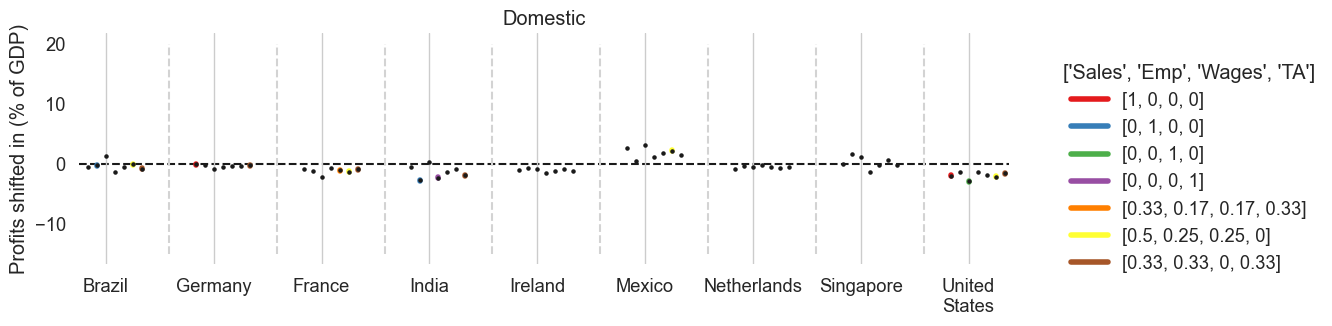

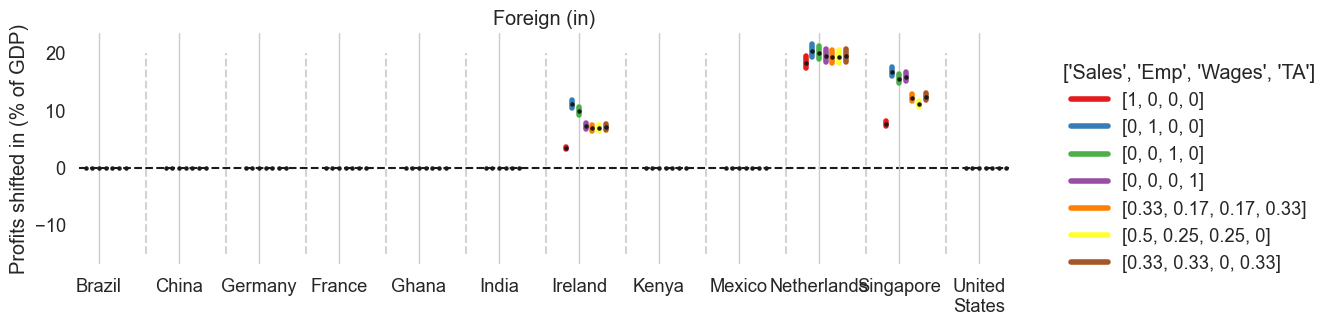

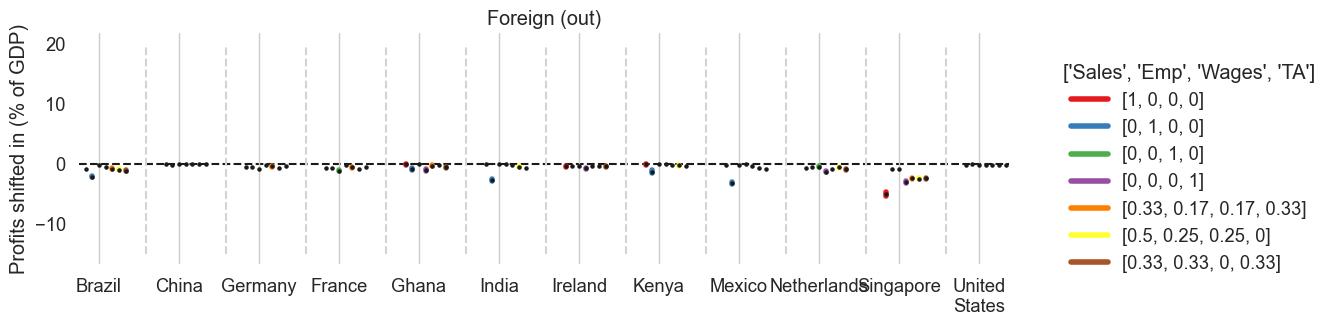

In [273]:
# UNTIL FIXED: SAVE FIGURES MANUALLY in /figures and /data/final/figures folders.
w2c = dict(zip(d_results.keys(),sns.color_palette("Set1",7)))
plot_results(countries,w2c,restriction="Domestic")
plot_results(countries,w2c,restriction="Foreign (in)")
plot_results(countries,w2c,restriction="Foreign (out)")

In [274]:
d = d_results[(0,0.5,0.5,0)].apply(lambda x: np.percentile(x[np.isfinite(x)],[2.5,25,50,75,97.5]).round(0),axis=1).reset_index()
d["ETR (%)"] = (100*d["iso3_d"].map(iso3_to_etr)).round(0)
d["cit"] = (100*d["iso3_d"].map(iso3_to_cit)).round(0)
d["gdp"] = (d["iso3_d"].map(iso3_to_gdp)).round(0)
d["sort"] = d[0].str[2]
d["PS (M)"] = d[0].str[2].apply(lambda x: f"{x/1E6:2,.0f}")
d["CI (M)"] = d.apply(lambda x: f"({x[0][0]/1E6:2,.0f}, {x[0][-1]/1E6:2,.0f})", axis=1)
d["PS (% GDP)"] = 100*d[0].str[2]/d["gdp"]
d["CI (% GDP)"] = d.apply(lambda x: f"({x[0][0]/x['gdp']:2.1%}, {x[0][-1]/x['gdp']:2.1%})", axis=1)
d["Type"] = d["Domestic"].map({0: "Foreign MNCs", 1: "Domestic MNCs"})
d["Country"] = d["iso3_d"].map(iso3_to_name)
display(d.sort_values(by="sort").tail(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])
display(d.sort_values(by="sort").head(10)[["Country","Type","PS (M)", "PS (% GDP)", "CI (M)", "CI (% GDP)","ETR (%)"]])

KeyError: (0, 0.5, 0.5, 0)

In [ ]:
iso3_to_dom["CAN"]

1

In [ ]:
d.loc[d["iso3_d"]=="BRA"]

,iso3_d,Domestic,0,ETR (%),cit,gdp,sort,PS (M),CI (M),PS (% GDP),CI (% GDP),Type,Country
51,BRA,Domestic,"[7163009962.0, 7312433888.0, 7384101821.0, 745...",25.0,34.0,1.916947e+12,7.384102e+09,"7,384","(7,163, 7,583)",0.385201,"(0.4%, 0.4%)",NaN,Brazil
52,BRA,Foreign (in),"[0.0, 0.0, 0.0, 0.0, 0.0]",25.0,34.0,1.916947e+12,0.000000e+00,0,"( 0, 0)",0.000000,"(0.0%, 0.0%)",NaN,Brazil
53,BRA,Foreign (out),"[-23584523970.0, -22955304656.0, -22580059696....",25.0,34.0,1.916947e+12,-2.258006e+10,"-22,580","(-23,585, -21,643)",-1.177918,"(-1.2%, -1.1%)",NaN,Brazil


In [ ]:
cost = []
costetr = []
mis = []
for weigths in [[0,0.5,0.5,0]]:
    weigths = weigths/np.sum(weigths)
    print(weigths)
    all_reps =  []
    all_pi =  []

    for rep,data in df.groupby("n_rep"):
        data = calculate_misalignment(data,weights=weigths,
                                      weights_var=["revt_pred","emp_pred","wages_pred","t_at_pred"],
                                      carve_out=None,
                                      carve_out_perc=0,
                                      pi_var="profits",
                                     thres_mis=0,
                                     max_etr=0.15)
        data["cit"] = data["iso3_d"].map(iso3_to_cit)
        data["cost"] = data["misaligned_profits"]*data["cit"]
        data["costetr"] = data["misaligned_profits"]*data["etr"]
        data = data.loc[data["misaligned_profits"]<0]
        mis.append(data["misaligned_profits"].sum())
        cost.append(data["cost"].sum())
        costetr.append(data["costetr"].sum())
        

[0.  0.5 0.5 0. ]


In [ ]:
(np.percentile(mis,[2.5,50,97.5])/1E9).round(0)

array([-1175., -1148., -1126.])

In [ ]:
(np.percentile(costetr,[2.5,50,97.5])/1E9).round(0)

array([-251., -245., -241.])

In [ ]:
(np.percentile(cost,[2.5,50,97.5])/1E9).round(0)

array([-319., -312., -306.])

In [ ]:
data

,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,n_rep,wages_pred,etr,cit,gdp,share_emp_pred,share_wages_pred,share_economy,share_profits,pi_theo_mis,misaligned_profits,cost,costetr
2349652,ARG,CHE,0.0,19242.123415,5.391713e+09,2.050413e+09,1.294807e+08,1.206327,15951.0,4.469528e+09,1.699715e+09,1.073346e+08,999.0,1.516934e+08,0.153573,0.300,5.248197e+11,1.495666e-04,3.831595e-05,9.394129e-05,3.083700e-05,3.944476e+08,-1.901079e+08,-5.703237e+07,-2.919549e+07
2349653,ARG,CHL,0.0,52413.705741,8.286165e+09,5.761548e+09,6.168943e+08,1.206327,43449.0,6.868921e+09,4.776108e+09,5.113823e+08,999.0,4.131982e+08,0.153573,0.300,5.248197e+11,4.074052e-04,1.043690e-04,2.558871e-04,1.469190e-04,1.074438e+09,-3.282772e+08,-9.848316e+07,-5.041461e+07
2349655,ARG,DEU,0.0,34268.133650,1.260960e+10,5.615151e+09,2.141243e+08,1.206327,28407.0,1.045288e+10,4.654750e+09,1.775010e+08,999.0,2.701494e+08,0.153573,0.300,5.248197e+11,2.663619e-04,6.823656e-05,1.672992e-04,5.099564e-05,7.024684e+08,-3.503761e+08,-1.051128e+08,-5.380841e+07
2349656,ARG,DNK,0.0,3659.996392,8.489798e+08,2.479935e+08,5.831435e+07,1.206327,3034.0,7.037725e+08,2.055773e+08,4.834041e+07,999.0,2.885322e+07,0.153573,0.300,5.248197e+11,2.844870e-05,7.287982e-06,1.786834e-05,1.388809e-05,7.502690e+07,-1.199089e+07,-3.597266e+06,-1.841480e+06
2349658,ARG,FRA,0.0,63039.034751,1.312041e+10,3.943054e+09,1.633330e+08,1.206327,52257.0,1.087633e+10,3.268644e+09,1.353969e+08,999.0,4.969619e+08,0.153573,0.300,5.248197e+11,4.899946e-04,1.255267e-04,3.077606e-04,3.889924e-05,1.292248e+09,-8.099715e+08,-2.429914e+08,-1.243900e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2351982,NPL,JPN,0.0,429.827983,3.141196e+07,1.089721e+07,4.012203e+06,2.755308,156.0,1.140053e+07,3.954988e+06,1.456173e+06,999.0,8.229344e+05,0.268861,0.200,3.311153e+10,3.340999e-06,2.078635e-07,1.774431e-06,9.555427e-07,7.450614e+06,-2.466983e+06,-4.933966e+05,-6.632748e+05
2351985,SDN,SAU,0.0,2560.000000,6.088536e+08,2.003509e+08,3.197342e+07,10.000000,256.0,6.088536e+07,2.003509e+07,3.197342e+06,999.0,3.555514e+06,0.030422,0.350,3.233378e+10,1.989856e-05,8.980810e-07,1.039832e-05,7.614760e-06,4.366124e+07,-8.385750e+06,-2.935013e+06,-2.551106e+05
2351987,VIR,IDN,0.0,1743.890662,1.281878e+08,3.656626e+07,5.545722e+06,2.418711,721.0,5.299837e+07,1.511808e+07,2.292842e+06,999.0,4.840110e+07,0.002349,0.231,3.922000e+09,1.355504e-05,1.222555e-05,1.289030e-05,1.320764e-06,5.412473e+07,-3.485435e+07,-8.051356e+06,-8.186628e+04
2351989,VIR,USA,0.0,5819.418770,4.046304e+09,1.079784e+09,-2.108114e+08,2.418711,2406.0,1.672917e+09,4.464296e+08,-8.715857e+07,999.0,1.615160e+08,0.002349,0.231,3.922000e+09,4.523362e-05,4.079704e-05,4.301533e-05,-5.020665e-05,1.806159e+08,-2.808404e+08,-6.487413e+07,-6.596409e+05


In [ ]:
countries = "IRL, NLD, SGP, FRA, DEU, USA, BRA, IND, MEX, GHA, KEN, CHN".split(", ")

(1.0, 0.0, 0.0, 0.0) [945.37392167 965.62040606 989.9234182 ]
(0.0, 1.0, 0.0, 0.0) [1172.36302114 1195.14386213 1222.40536669]
(0.0, 0.0, 1.0, 0.0) [1145.65205862 1168.69928403 1195.43240921]
(0.0, 0.0, 0.0, 1.0) [872.65788452 894.55436534 920.55228214]
(0.3333333333333333, 0.16666666666666666, 0.16666666666666666, 0.3333333333333333) [927.2142539  948.05503599 972.6871194 ]
(0.5, 0.25, 0.25, 0.0) [1009.75596536 1030.65534634 1055.38446524]
(0.0, 0.5, 0.5, 0.0) [1126.02617794 1148.24538408 1174.60741942]


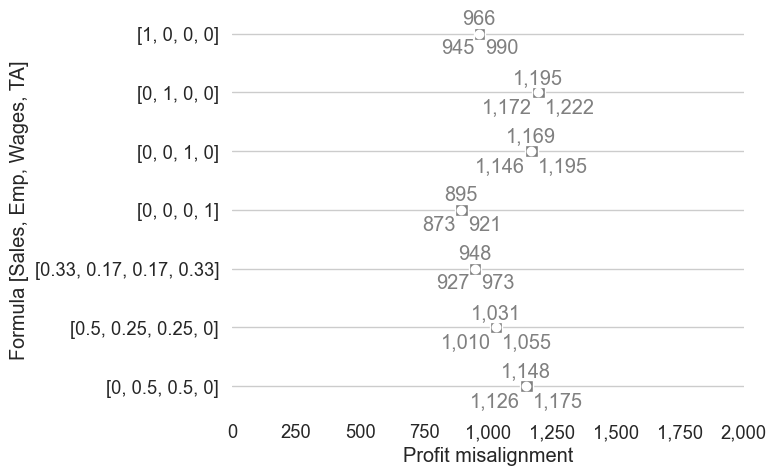

In [ ]:
plt.figure(figsize=(8,5))
i = 0
for alpha in d_results:
    i += 1
    d = d_results[alpha].copy()#.xs(i, level='Domestic', drop_level=False)
    d[d<0] = 0
    d = d.groupby("iso3_d").sum()
    
    perc = np.percentile(d.sum(),[2.5,50,97.5])/1E9
    print(alpha,perc)
    plt.barh(i,perc[-1]-perc[0],left=perc[0],color="grey",height=0.2)
    plt.scatter(perc[1],i,color="white",zorder=9)
    plt.annotate(f"{perc[1]:2,.0f}",(perc[1],i-0.25),va="center",ha="center",color="gray")
    plt.annotate(f"{perc[0]:2,.0f}",(perc[0],i+0.25),va="center",ha="right",color="grey")
    plt.annotate(f"{perc[-1]:2,.0f}",(perc[-1],i+0.25),va="center",ha="left",color="grey")
    
plt.yticks(range(1,i+1),[[np.round(_,2) if _!=int(_) else int(_) for _ in k] for k in d_results.keys()])
plt.gca().grid(axis="x")
sns.despine(bottom=True,left=True)
plt.xlim(0,2000)
plt.xlabel("Profit misalignment")
plt.ylabel("Formula [Sales, Emp, Wages, TA]")
plt.gca().invert_yaxis()


plt.gca().xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig(f"{path_figures}/alternative_formulas.png",dpi=300)
plt.savefig(f"{path_files_final_figures}/alternative_formulas.png",dpi=300)

In [ ]:
tca_entry = iso3_to_cit.get("MHL")
print(tca_entry)

0.0
